In [120]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize, differential_evolution
from scipy.stats import norm
import glob
import os
from sklearn.preprocessing import StandardScaler
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

class BBIAnalyzer:
    def __init__(self, folder_path=".", file_pattern="Prove BBI-68 VIDIT#Set*#*.TXT"):
        """
        Analizzatore per dati BBI-68 con fitting tramite massimizzazione della verosimiglianza
        
        Parameters:
        -----------
        folder_path : str
            Percorso della cartella contenente i file
        file_pattern : str
            Pattern per i file da analizzare
        """
        self.folder_path = folder_path
        self.file_pattern = file_pattern
        self.all_data = {}  # Dati aggregati per segmento
        self.results = {}
        
    def load_data(self, file_path):
        """Carica un singolo file di dati"""
        try:
            # Prima leggi il file per trovare la riga corretta dell'header
            with open(file_path, 'r', encoding='utf-8') as f:
                lines = f.readlines()
            
            # Trova la riga con i nomi delle colonne (quella che contiene "Time (s)")
            header_row = 0
            for i, line in enumerate(lines):
                if 'Time (s)' in line and 'Pd (nm)' in line:
                    header_row = i
                    break
            
            # Carica il file saltando le righe prima dell'header
            df = pd.read_csv(file_path, sep='\t', encoding='utf-8', 
                           skiprows=header_row, low_memory=False)
            
            # Pulisci i nomi delle colonne
            df.columns = df.columns.str.strip()
            
            # Mappa i nomi delle colonne ai nomi standard
            column_mapping = {
                'Pd (nm)': 'Pd',
                'Fn (mN)': 'Fn', 
                'Time (s)': 'Time',
                'SegmentID': 'SegmentID',
                'FnRef (mN)': 'FnRef',
                'Res (ohm)': 'Res'
            }
            
            df = df.rename(columns=column_mapping)
            
            # Converti i valori numerici
            numeric_columns = ['Time', 'Pd', 'Fn', 'FnRef', 'SegmentID', 'Res']
            for col in numeric_columns:
                if col in df.columns:
                    df[col] = pd.to_numeric(df[col], errors='coerce')
            
            # Rimuovi righe con valori NaN nelle colonne essenziali
            df = df.dropna(subset=['Pd', 'Fn', 'SegmentID'])
            
            # Aggiungi colonna con nome del file per tracciare l'origine
            df['file_name'] = os.path.basename(file_path)
            
            return df
            
        except Exception as e:
            print(f"Errore nel caricamento di {file_path}: {e}")
            return None
    
    def separate_loading_unloading(self, df):
        """
        Separa i dati in base ai segmenti:
        - SegmentID = 1: load (carico)
        - SegmentID = 2: hold (mantenimento)
        - SegmentID = 3: unload (scarico)
        - SegmentID = 4: hold (mantenimento)
        - SegmentID = 5: unload più leggero
        """
        segments = {}
        
        if 'SegmentID' in df.columns:
            # Definisci i nomi dei segmenti
            segment_names = {
                1: 'loading',
                2: 'hold1', 
                3: 'unloading',
                4: 'hold2',
                5: 'unload_light'
            }
            
            for seg_id, seg_name in segment_names.items():
                seg_data = df[df['SegmentID'] == seg_id].copy()
                if len(seg_data) > 0:
                    # Pulisci i dati per ogni segmento
                    cleaned = seg_data[
                        (seg_data['Pd'] >= 0) & 
                        (seg_data['Fn'] >= -0.001)
                    ].copy()
                    
                    if len(cleaned) > 0:
                        segments[seg_name] = cleaned
        
        return segments
    
    def model_function_powerlaw(self, h, params):
        """
        Funzione del modello per carico/scarico: F = a * (h - h0)^m
        """
        a, h0, m = params
        h_eff = np.maximum(h - h0, 1e-10)
        return a * (h_eff ** m)
    
    def model_function_constant(self, h, params):
        """
        Funzione del modello per holding: F = c (costante)
        """
        c = params[0]
        return np.full_like(h, c)
    
    def log_likelihood_powerlaw(self, params, h, F_obs):
        """
        Log-verosimiglianza per il modello power law
        """
        a, h0, m, sigma = params
        
        # Vincoli sui parametri
        if a <= 0 or sigma <= 0 or m <= 0:
            return -np.inf
        
        if h0 < 0 or h0 >= np.min(h):
            return -np.inf
        
        try:
            F_pred = self.model_function_powerlaw(h, [a, h0, m])
            residuals = F_obs - F_pred
            
            log_lik = -0.5 * len(h) * np.log(2 * np.pi * sigma**2) - \
                     0.5 * np.sum(residuals**2) / sigma**2
            
            return log_lik
        except:
            return -np.inf
    
    def log_likelihood_constant(self, params, h, F_obs):
        """
        Log-verosimiglianza per il modello costante
        """
        c, sigma = params
        
        if sigma <= 0:
            return -np.inf
        
        try:
            F_pred = self.model_function_constant(h, [c])
            residuals = F_obs - F_pred
            
            log_lik = -0.5 * len(h) * np.log(2 * np.pi * sigma**2) - \
                     0.5 * np.sum(residuals**2) / sigma**2
            
            return log_lik
        except:
            return -np.inf
    
    def fit_powerlaw_curve(self, h, F, curve_type="loading"):
        """
        Fit con modello power law per carico/scarico
        """
        # Filtra dati validi
        mask = (h > 0) & (F > 0) & np.isfinite(h) & np.isfinite(F)
        h_clean = h[mask]
        F_clean = F[mask]
        
        if len(h_clean) < 5:
            return {'success': False, 'message': 'Dati insufficienti'}
        
        # Valori iniziali
        h_range = np.max(h_clean) - np.min(h_clean)
        F_range = np.max(F_clean) - np.min(F_clean)
        
        if h_range == 0 or F_range == 0:
            return {'success': False, 'message': 'Range dati nullo'}
        
        a_init = F_range / (h_range ** 1.5)
        h0_init = np.min(h_clean) * 0.1
        m_init = 1.5
        sigma_init = np.std(F_clean) * 0.1
        
        # Bounds
        bounds = [
            (1e-6, F_range * 100),
            (0, np.min(h_clean) * 0.9),
            (0.1, 5.0),
            (1e-6, np.std(F_clean) * 2)
        ]
        
        def objective(params):
            return -self.log_likelihood_powerlaw(params, h_clean, F_clean)
        
        result = differential_evolution(
            objective,
            bounds,
            seed=42,
            maxiter=1000,
            atol=1e-8,
            polish=True
        )
        
        if result.success:
            a_opt, h0_opt, m_opt, sigma_opt = result.x
            
            F_pred = self.model_function_powerlaw(h_clean, [a_opt, h0_opt, m_opt])
            rmse = np.sqrt(np.mean((F_clean - F_pred)**2))
            
            return {
                'a': a_opt,
                'h0': h0_opt,
                'm': m_opt,
                'sigma': sigma_opt,
                'log_likelihood': -result.fun,
                'rmse': rmse,
                'success': True,
                'h_pred': h_clean,
                'F_pred': F_pred,
                'n_points': len(h_clean),
                'model_type': 'powerlaw'
            }
        else:
            return {'success': False, 'message': result.message}
    
    def fit_constant_curve(self, h, F, curve_type="holding"):
        """
        Fit con modello costante per holding
        """
        # Filtra dati validi
        mask = (h > 0) & (F > 0) & np.isfinite(h) & np.isfinite(F)
        h_clean = h[mask]
        F_clean = F[mask]
    
        if len(h_clean) < 3:
            return {'success': False, 'message': 'Dati insufficienti'}
        
        # Valori iniziali
        c_init = np.mean(F_clean)
        sigma_init = np.std(F_clean)
        
        if sigma_init == 0:
            sigma_init = c_init * 0.01
        
        # Bounds
        bounds = [
            (0, np.max(F_clean) * 2),
            (1e-6, np.std(F_clean) * 10)
        ]
        
        def objective(params):
            return -self.log_likelihood_constant(params, h_clean, F_clean)
        
        result = differential_evolution(
            objective,
            bounds,
            seed=42,
            maxiter=500,
            atol=1e-8,
            polish=True
        )
        
        if result.success:
            c_opt, sigma_opt = result.x
            
            F_pred = self.model_function_constant(h_clean, [c_opt])
            rmse = np.sqrt(np.mean((F_clean - F_pred)**2))
            
            return {
                'c': c_opt,
                'sigma': sigma_opt,
                'log_likelihood': -result.fun,
                'rmse': rmse,
                'success': True,
                'h_pred': h_clean,
                'F_pred': F_pred,
                'n_points': len(h_clean),
                'model_type': 'constant'
            }
        else:
            return {'success': False, 'message': result.message}
    
    def collect_all_data(self):
        """Raccoglie tutti i dati da tutti i file e li aggrega per segmento"""
        full_pattern = os.path.join(self.folder_path, self.file_pattern)
        files = glob.glob(full_pattern)
        
        if not files:
            # Prova pattern alternativi
            alt_patterns = ["*.txt", "*.TXT", "*.csv", "*.CSV", "BBI*.txt", "*BBI*.TXT"]
            for pattern in alt_patterns:
                alt_full_pattern = os.path.join(self.folder_path, pattern)
                files = glob.glob(alt_full_pattern)
                if files:
                    print(f"Trovati {len(files)} file con pattern alternativo: {pattern}")
                    break
        
        if not files:
            print(f"Nessun file trovato nella cartella: {self.folder_path}")
            return
        
        print(f"Raccogliendo dati da {len(files)} file...")
        
        # Inizializza dizionario per raccogliere dati aggregati
        self.all_data = {
            'loading': {'h': [], 'F': [], 'files': []},
            'hold1': {'h': [], 'F': [], 'files': []},
            'unloading': {'h': [], 'F': [], 'files': []},
            'hold2': {'h': [], 'F': [], 'files': []},
            'unload_light': {'h': [], 'F': [], 'files': []}
        }
        
        successful_files = 0
        
        for file_path in files:
            file_name = os.path.basename(file_path)
            df = self.load_data(file_path)
            
            if df is not None:
                segments = self.separate_loading_unloading(df)
                
                for seg_name, seg_data in segments.items():
                    if seg_name in self.all_data and len(seg_data) > 0:
                        self.all_data[seg_name]['h'].extend(seg_data['Pd'].values)
                        self.all_data[seg_name]['F'].extend(seg_data['Fn'].values)
                        self.all_data[seg_name]['files'].extend([file_name] * len(seg_data))
                
                successful_files += 1
        
        print(f"Dati raccolti da {successful_files} file con successo")
        
        # Converti in array numpy
        for seg_name in self.all_data:
            if self.all_data[seg_name]['h']:
                self.all_data[seg_name]['h'] = np.array(self.all_data[seg_name]['h'])
                self.all_data[seg_name]['F'] = np.array(self.all_data[seg_name]['F'])
                print(f"Segmento {seg_name}: {len(self.all_data[seg_name]['h'])} punti totali")
            else:
                print(f"Segmento {seg_name}: nessun dato")
    
    def fit_all_segments(self):
        """Fit di tutti i segmenti usando i dati aggregati"""
        if not self.all_data:
            print("Nessun dato disponibile. Eseguire prima collect_all_data()")
            return
        
        self.results = {}
        
        # Segmenti che usano power law
        powerlaw_segments = ['loading', 'unloading', 'unload_light']
        
        # Segmenti che usano modello costante
        constant_segments = ['hold1', 'hold2']
        
        for seg_name in powerlaw_segments:
            if seg_name in self.all_data and len(self.all_data[seg_name]['h']) > 0:
                print(f"Fitting segmento {seg_name} con modello power law...")
                h = self.all_data[seg_name]['h']
                F = self.all_data[seg_name]['F']
                
                result = self.fit_powerlaw_curve(h, F, seg_name)
                if result['success']:
                    self.results[seg_name] = result
                    print(f"✓ {seg_name}: a={result['a']:.6f}, h0={result['h0']:.6f}, m={result['m']:.6f}, RMSE={result['rmse']:.6f}")
                else:
                    print(f"✗ Errore nel fit di {seg_name}: {result['message']}")
        
        for seg_name in constant_segments:
            if seg_name in self.all_data and len(self.all_data[seg_name]['h']) > 0:
                print(f"Fitting segmento {seg_name} con modello costante...")
                h = self.all_data[seg_name]['h']
                F = self.all_data[seg_name]['F']
                
                result = self.fit_constant_curve(h, F, seg_name)
                if result['success']:
                    self.results[seg_name] = result
                    print(f"✓ {seg_name}: c={result['c']:.6f}, RMSE={result['rmse']:.6f}")
                else:
                    print(f"✗ Errore nel fit di {seg_name}: {result['message']}")
    
    def plot_results(self, user_ranges):
        """Visualizza e salva i risultati del fit aggregato per ogni segmento"""
        if not self.results:
            print("Nessun risultato da visualizzare")
            return
        
        colors = {
            'loading': 'blue',
            'hold1': 'green',
            'unloading': 'red',
            'hold2': 'orange',
            'unload_light': 'purple'
        }
        
        output_folder = r"C:\Users\geard\OneDrive\Download\Tesi\stima_parametri\dataset_2"
        
        # Crea un grafico separato per ogni segmento
        for seg_name, result in self.results.items():
            fig, ax = plt.subplots(figsize=(10, 8))
            
            # Dati originali (campionati per evitare troppi punti)
            h_orig = self.all_data[seg_name]['h']
            F_orig = self.all_data[seg_name]['F']
            
            # Campiona i dati se troppi punti
            if len(h_orig) > 10000:
                indices = np.random.choice(len(h_orig), 10000, replace=False)
                h_sample = h_orig[indices]
                F_sample = F_orig[indices]
            else:
                h_sample = h_orig
                F_sample = F_orig
            
            color = colors.get(seg_name, 'gray')
            ax.scatter(F_sample, h_sample, alpha=0.3, s=2, color=color, label='Dati sperimentali')
            
            # Fit
            if result['success']:
                F_fit = result['F_pred']
                h_fit = result['h_pred']
                
                # Ordina per il plot
                sort_idx = np.argsort(F_fit)
                ax.plot(F_fit[sort_idx], h_fit[sort_idx], 'r-', linewidth=3, label='Fit')
                
                # Titolo con parametri
                if result['model_type'] == 'powerlaw':
                    title = f"Segmento: {seg_name.upper()}\n"
                    title += f"Modello: F = a × (h - h₀)ᵐ\n"
                    title += f"a = {result['a']:.3e}\n"
                    title += f"h₀ = {result['h0']:.3f} nm\n"
                    title += f"m = {result['m']:.3f}\n"
                    title += f"RMSE = {result['rmse']:.3f} mN"
                else:  # constant
                    title = f"Segmento: {seg_name.upper()}\n"
                    title += f"Modello: F = c (costante)\n"
                    title += f"c = {result['c']:.3f} mN\n"
                    title += f"RMSE = {result['rmse']:.3f} mN"
                
                ax.set_title(title, fontsize=14, pad=20)
                
                # Aggiungi informazioni sui dati
                ax.text(0.02, 0.98, f"Punti utilizzati: {result['n_points']:,}", 
                       transform=ax.transAxes, fontsize=12, verticalalignment='top',
                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
            
            ax.set_xlabel('Fn (mN)', fontsize=12)
            ax.set_ylabel('Pd (nm)', fontsize=12)
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize=12)
            
            # Migliora l'aspetto
            ax.tick_params(axis='both', which='major', labelsize=10)
            
            plt.tight_layout()
            
            # Salva il plot del singolo segmento
            if output_folder:
                output_path = Path(output_folder) / f"fit_{seg_name}.png"
                plt.savefig(output_path, dpi=300, bbox_inches='tight')
                print(f"✅ Plot {seg_name} salvato: {output_path}")
            
            plt.show()
            plt.close(fig)
        self.plot_continuous_results(user_ranges)
        
    def plot_continuous_results(self, user_ranges):
       """
       Visualizza i risultati del fit continuo.
       Se user_ranges è fornito, usa SOLO i range di h (profondità) 
       definiti dall'utente per ogni segmento.
       """
       if not self.results:
           print("Nessun risultato continuo da visualizzare")
           return
    
       fig, ax = plt.subplots(figsize=(14, 10))
       
       colors = {
           'loading': 'blue',
           'hold1': 'green',
           'unloading': 'red',
           'hold2': 'orange',
           'unload_light': 'purple'
       }
       
       # Se non sono forniti i range utente, usa il comportamento originale
       if user_ranges is None:
           # Plot dei dati sperimentali
           for seg_name in ['loading', 'hold1', 'unloading', 'hold2', 'unload_light']:
               if seg_name in self.all_data and len(self.all_data[seg_name]['h']) > 0:
                   h_data = self.all_data[seg_name]['h']
                   F_data = self.all_data[seg_name]['F']
                   
                   # Campiona se troppi punti
                   if len(h_data) > 5000:
                       indices = np.random.choice(len(h_data), 5000, replace=False)
                       h_sample = h_data[indices]
                       F_sample = F_data[indices]
                   else:
                       h_sample = h_data
                       F_sample = F_data
                   
                   color = colors.get(seg_name, 'gray')
                   ax.scatter(F_sample, h_sample, alpha=0.3, s=1, 
                             color=color, label=f'{seg_name} (dati)')
           
           # Plot dei fit continui usando i dati originali
           for seg_name, result in self.results.items():
               if result['success'] and seg_name in self.all_data:
                   if result['model_type'] == 'powerlaw':
                       # Per le power law, crea una curva liscia
                       h_data = self.all_data[seg_name]['h']
                       h_smooth = np.linspace(np.min(h_data), np.max(h_data), 200)
                       h_eff = np.maximum(h_smooth - result['h0'], 1e-10)
                       F_smooth = result['a'] * (h_eff ** result['m'])
                       
                       color = 'darkred' if 'unload' in seg_name else 'darkblue'
                       ax.plot(F_smooth, h_smooth, '-', linewidth=3, 
                              color=color, label=f'{seg_name} (fit)')
                   
                   elif result['model_type'] == 'constant':
                       # Per le costanti, linea orizzontale
                       h_data = self.all_data[seg_name]['h']
                       h_range = np.linspace(np.min(h_data), np.max(h_data), 100)
                       F_const = np.full_like(h_range, result['c'])
                       
                       ax.plot(F_const, h_range, '-', linewidth=3, 
                              color='darkgreen', label=f'{seg_name} (fit)')
           
           title_suffix = ""
       
       else:
           # Usa i range definiti dall'utente
           for seg_name, result in self.results.items():
               if not result.get('success', False):
                   continue
               if seg_name not in user_ranges:
                   continue
                   
               # Estrai h_min e h_max dall'input utente
               h_min = user_ranges[seg_name]['h_min']
               h_max = user_ranges[seg_name]['h_max']
               
               if result['model_type'] == 'powerlaw':
                   # Genera la curva nel dominio h_min–h_max
                   h_smooth = np.linspace(h_min, h_max, 200)
                   h_eff = np.maximum(h_smooth - result['h0'], 1e-10)
                   F_smooth = result['a'] * (h_eff ** result['m'])
                   
                   color = 'darkred' if 'unloading' in seg_name else ('darkblue' if 'loading' in seg_name else 'gray')
                   ax.plot(F_smooth, h_smooth, '-', linewidth=3, 
                          color=color, label=f'{seg_name} (fit)')
               
               elif result['model_type'] == 'constant':
                   # Costante: linea verticale in h
                   h_line = np.array([h_min, h_max])
                   F_line = np.full(2, result['c'])
                   ax.plot(F_line, h_line, '-', linewidth=3, 
                          color='darkgreen' if 'hold1' in seg_name else 'black', label=f'{seg_name} (fit)')
           
       ax.set_xlabel('Fn (mN)', fontsize=14)
       ax.set_ylabel('Pd (nm)', fontsize=14)
       ax.set_title(f'Fit Continuo BBI-68', fontsize=16)
       ax.grid(True, alpha=0.3)
       ax.legend(fontsize=10, loc='lower right')
       ax.tick_params(axis='both', which='major', labelsize=12)
       
       plt.tight_layout()
       
       # Salva il plot
       output_folder = r"C:\Users\geard\OneDrive\Download\Tesi\stima_parametri\dataset_2"
       if output_folder:
           filename = "fit_continuo.png" if user_ranges else "fit_continuo_completo.png"
           output_path = Path(output_folder) / filename
           plt.savefig(output_path, dpi=300, bbox_inches='tight')
           print(f"✅ Plot continuo salvato: {output_path}")
       
       plt.show()
        
    
    def summary_results(self):
        """Crea un riassunto dei risultati"""
        if not self.results:
            print("Nessun risultato da riassumere")
            return
        
        print("\n=== RISULTATI AGGREGATI ===")
        
        for seg_name, result in self.results.items():
            print(f"\n{seg_name.upper()}:")
            print(f"  Punti utilizzati: {result['n_points']}")
            print(f"  RMSE: {result['rmse']:.6f}")
            print(f"  Log-likelihood: {result['log_likelihood']:.2f}")
            
            if result['model_type'] == 'powerlaw':
                print(f"  Parametri: a={result['a']:.6e}, h0={result['h0']:.6f}, m={result['m']:.6f}")
            else:
                print(f"  Parametri: c={result['c']:.6f}")
    
    def save_results(self):
        """Salva i risultati in un file"""
        if not self.results:
            print("Nessun risultato da salvare")
            return
        
        output_path = r"C:\Users\geard\OneDrive\Download\Tesi\stima_parametri\dataset_2\aggregated_results.txt"
        
        with open(output_path, 'w', encoding='utf-8') as f:
            f.write("=== RISULTATI AGGREGATI ANALISI BBI ===\n\n")
            
            for seg_name, result in self.results.items():
                f.write(f"{seg_name.upper()}:\n")
                f.write(f"  Punti utilizzati: {result['n_points']}\n")
                f.write(f"  RMSE: {result['rmse']:.6f}\n")
                f.write(f"  Log-likelihood: {result['log_likelihood']:.2f}\n")
                
                if result['model_type'] == 'powerlaw':
                    f.write(f"  Parametri:\n")
                    f.write(f"    a = {result['a']:.6e}\n")
                    f.write(f"    h0 = {result['h0']:.6f}\n")
                    f.write(f"    m = {result['m']:.6f}\n")
                else:
                    f.write(f"  Parametri:\n")
                    f.write(f"    c = {result['c']:.6f}\n")
                
                f.write(f"  Modello: {result['model_type']}\n\n")
        
        print(f"✅ Risultati salvati in: {output_path}")

Raccogliendo dati da 49 file...
Dati raccolti da 49 file con successo
Segmento loading: 4894 punti totali
Segmento hold1: 3923 punti totali
Segmento unloading: 4412 punti totali
Segmento hold2: 29405 punti totali
Segmento unload_light: 490 punti totali
Fitting segmento loading con modello power law...
✓ loading: a=0.000187, h0=0.076300, m=1.925362, RMSE=0.081048
Fitting segmento unloading con modello power law...
✓ unloading: a=0.016975, h0=133.325209, m=1.265911, RMSE=0.130268
Fitting segmento unload_light con modello power law...
✓ unload_light: a=0.005573, h0=112.032059, m=1.355333, RMSE=0.104796
Fitting segmento hold1 con modello costante...
✓ hold1: c=9.983785, RMSE=0.073933
Fitting segmento hold2 con modello costante...
✓ hold2: c=1.001259, RMSE=0.027563

=== RISULTATI AGGREGATI ===

LOADING:
  Punti utilizzati: 4894
  RMSE: 0.081048
  Log-likelihood: 5352.95
  Parametri: a=1.865290e-04, h0=0.076300, m=1.925362

UNLOADING:
  Punti utilizzati: 4412
  RMSE: 0.130268
  Log-likelihoo

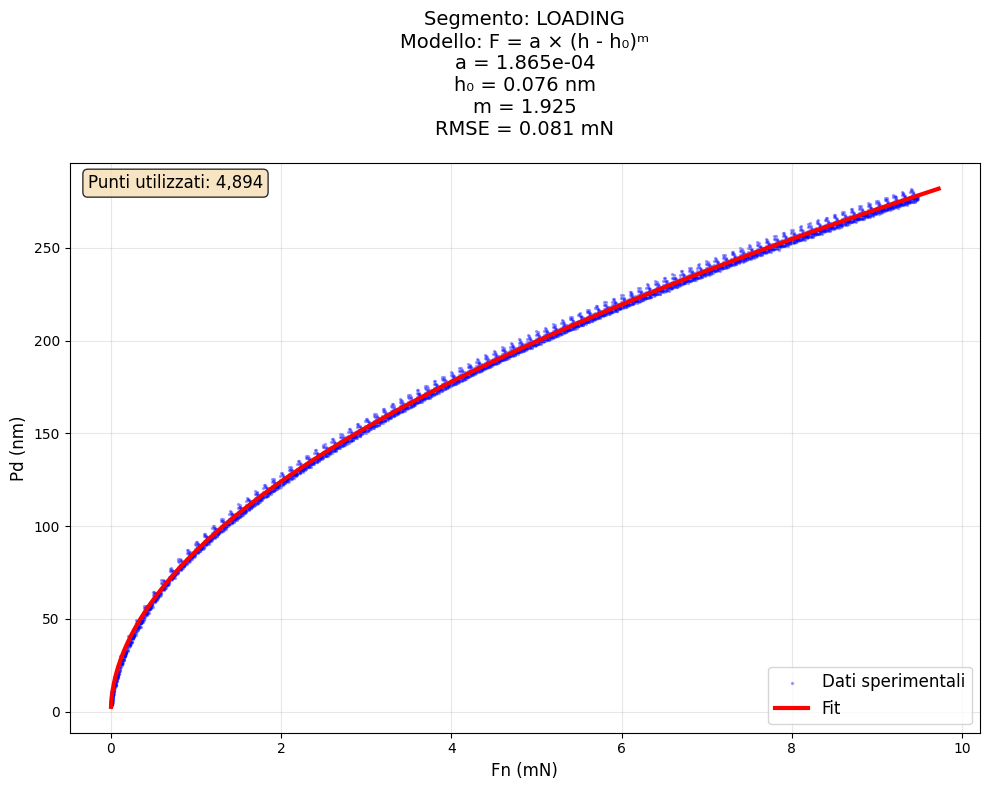

✅ Plot unloading salvato: C:\Users\geard\OneDrive\Download\Tesi\stima_parametri\dataset_2\fit_unloading.png


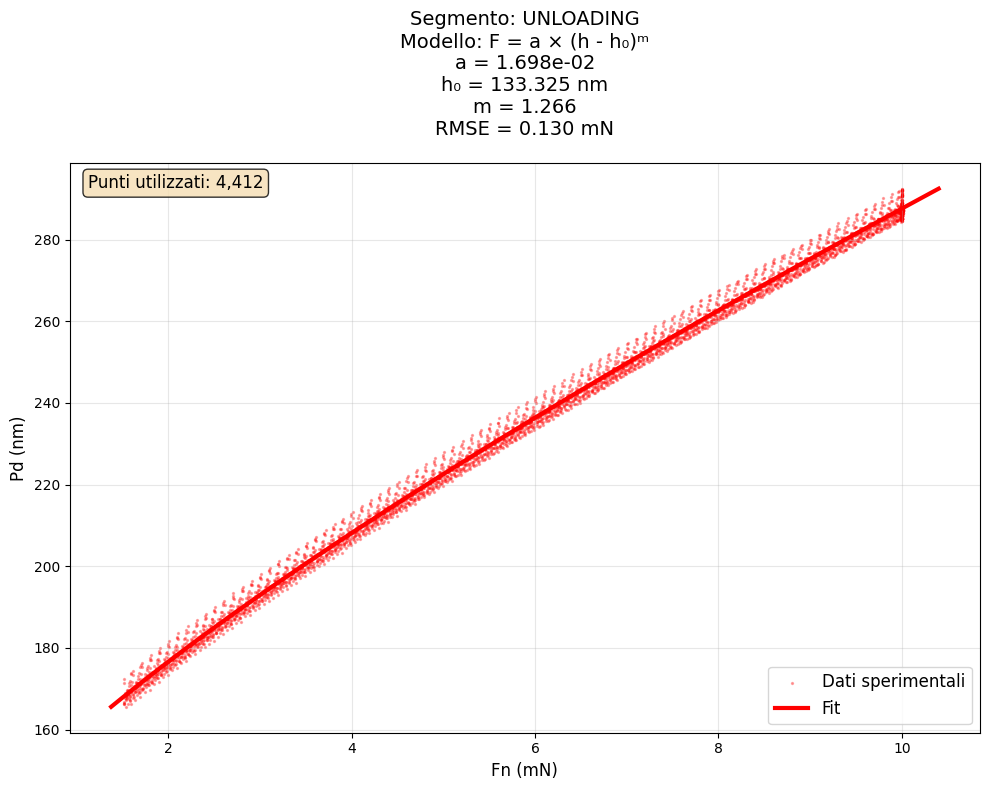

✅ Plot unload_light salvato: C:\Users\geard\OneDrive\Download\Tesi\stima_parametri\dataset_2\fit_unload_light.png


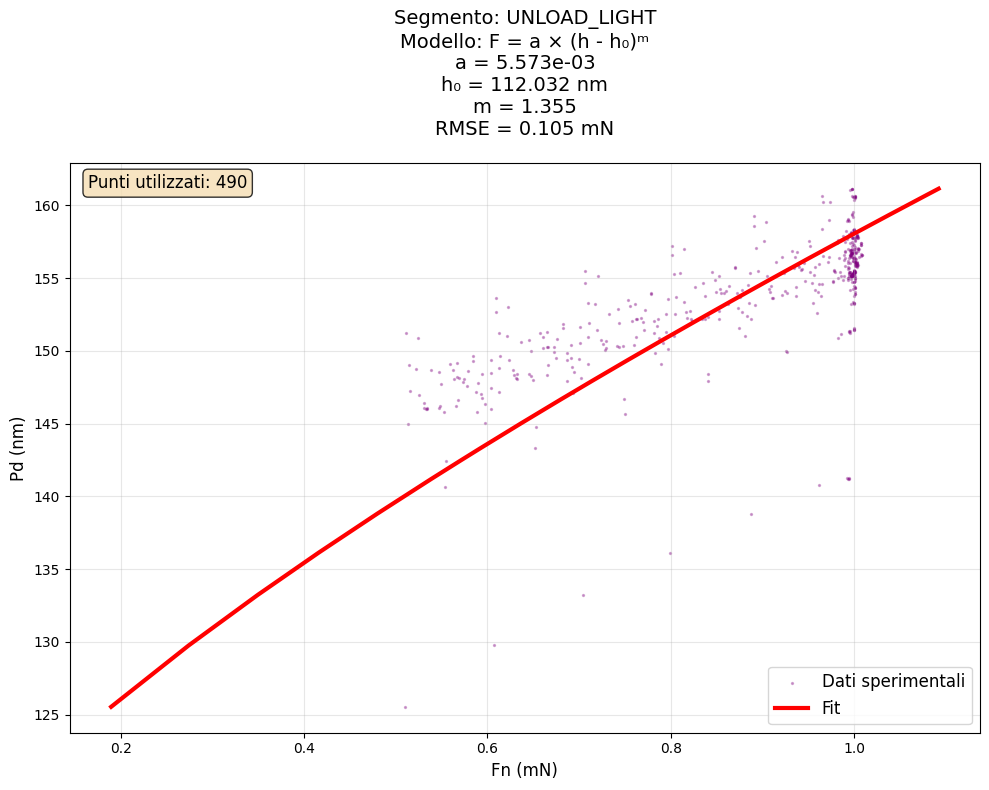

✅ Plot hold1 salvato: C:\Users\geard\OneDrive\Download\Tesi\stima_parametri\dataset_2\fit_hold1.png


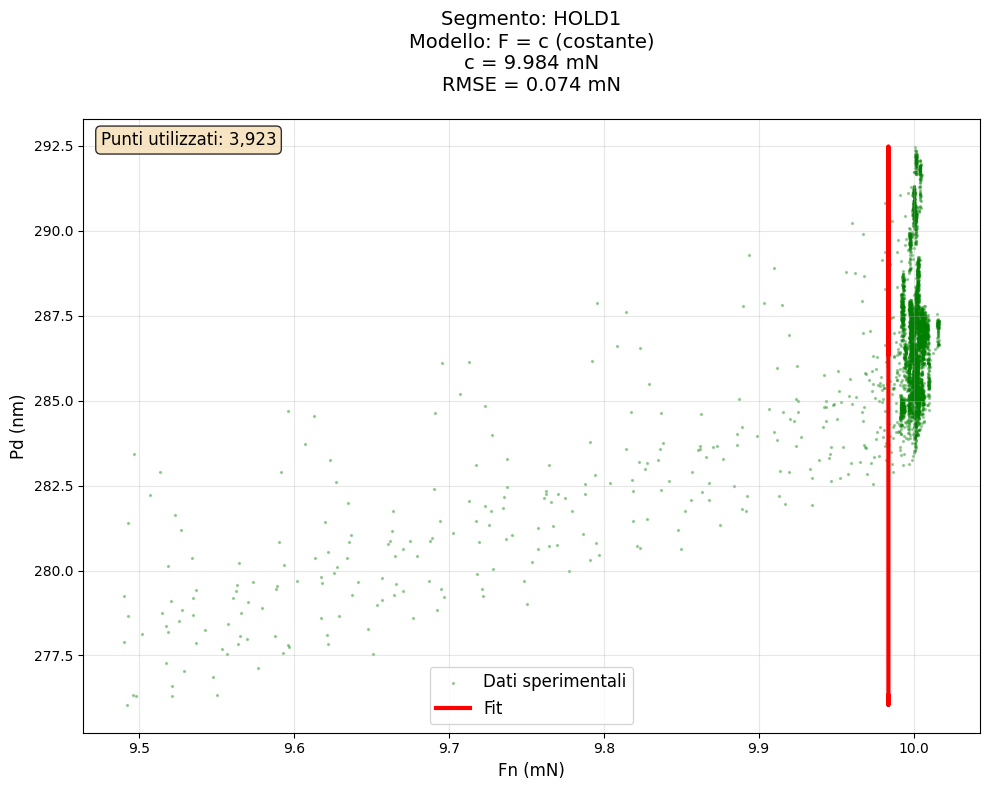

✅ Plot hold2 salvato: C:\Users\geard\OneDrive\Download\Tesi\stima_parametri\dataset_2\fit_hold2.png


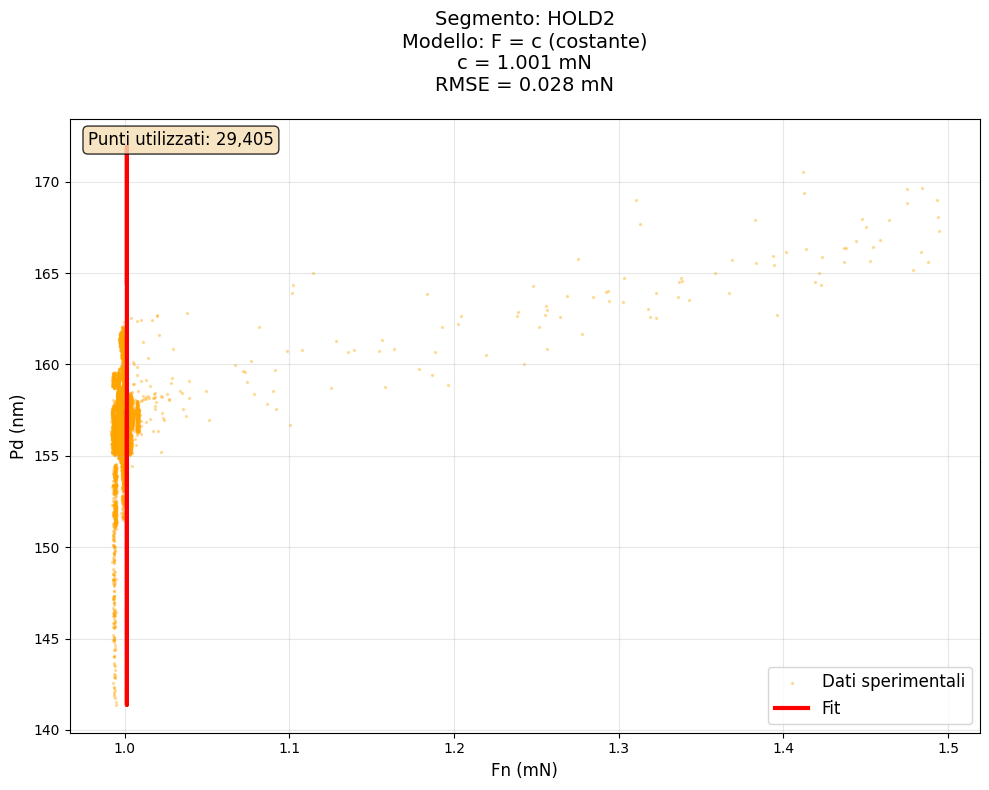

✅ Plot continuo salvato: C:\Users\geard\OneDrive\Download\Tesi\stima_parametri\dataset_2\fit_continuo.png


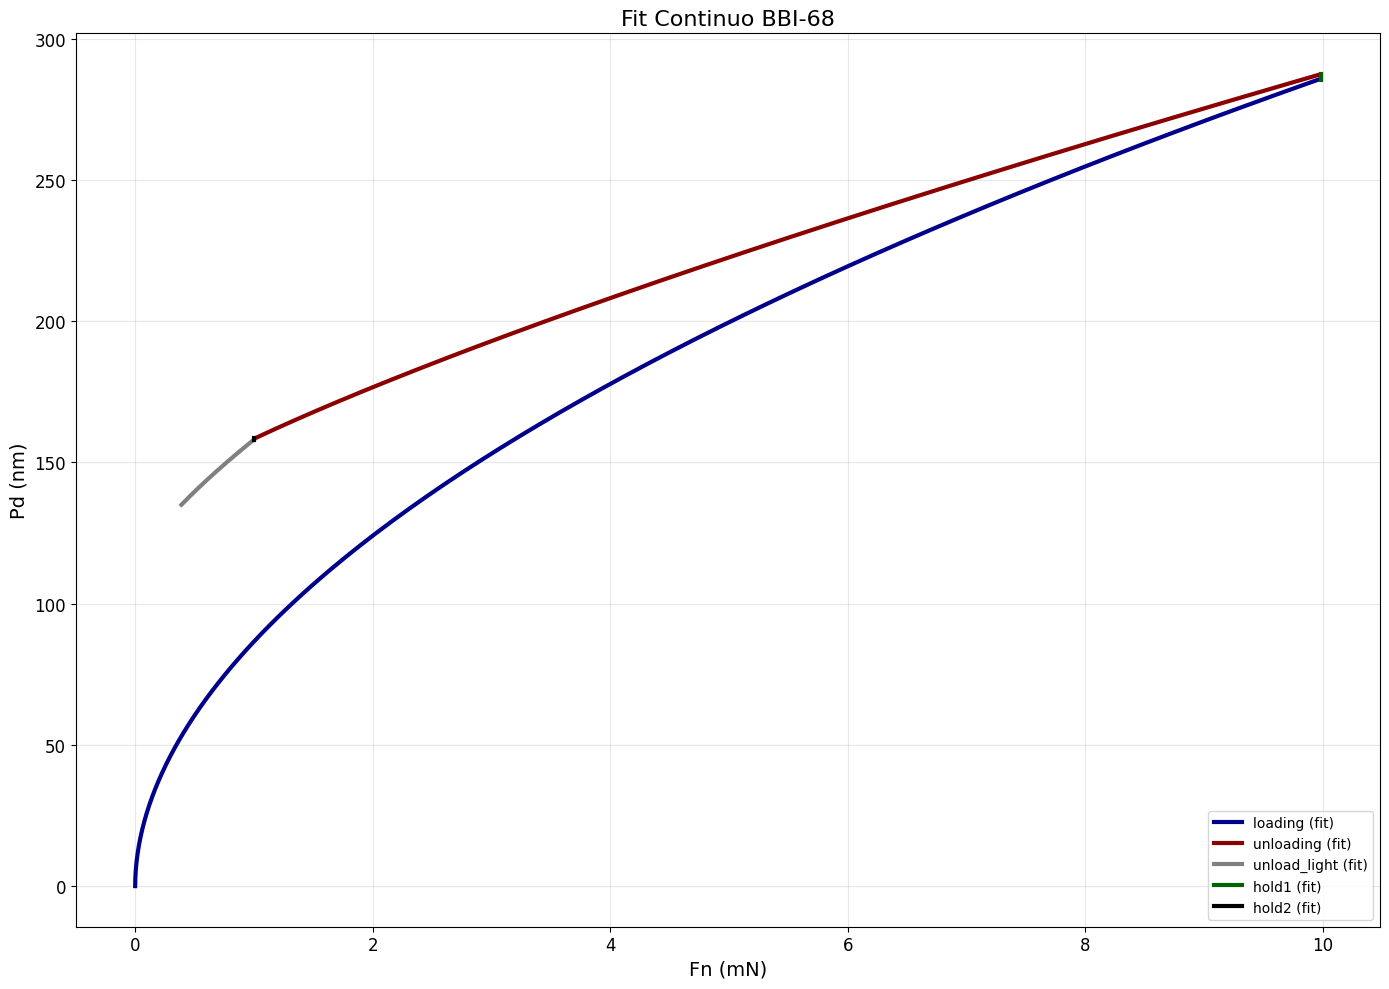

✅ Risultati salvati in: C:\Users\geard\OneDrive\Download\Tesi\stima_parametri\dataset_2\aggregated_results.txt


In [121]:
# Aggiungi questa funzione al main
if __name__ == "__main__":
    # Dopo aver eseguito l'analisi principale...
    
    # INSERISCI QUI IL TUO PERCORSO CARTELLA
    folder_path = r"C:\Users\geard\OneDrive\Download\Tesi\dati_ts\dataset_2"
    
    # Inizializza l'analizzatore
    analyzer = BBIAnalyzer(
        folder_path=folder_path,
        file_pattern="*.TXT"
    )
    
    # Raccogli tutti i dati
    analyzer.collect_all_data()
    
    # Fit di tutti i segmenti
    analyzer.fit_all_segments()
    
    # Mostra risultati
    analyzer.summary_results()
    
    user_ranges = {
    'loading':        {'h_min':   0.0,  'h_max': 285.5},
    'hold1':          {'h_min':   285.5,  'h_max':  287.5},
    'unloading':      {'h_min': 158.5,  'h_max': 287.2},
    'hold2':          {'h_min':   157.9,  'h_max': 158.5},
    'unload_light':{'h_min': 135,  'h_max': 158}
    }

    # Visualizza grafici
    analyzer.plot_results(user_ranges)
    
    # Salva risultati
    analyzer.save_results()